### imports

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd()

# If notebook is opened from notebooks/, move one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

# VEDAI paths
VEDAI_RAW = PROJECT_ROOT / "data" / "vedai" / "raw"
IMG_DIR = VEDAI_RAW / "Vehicules512"
ANN_DIR = VEDAI_RAW / "Annotations512"

print("Project root:", PROJECT_ROOT)
print("VEDAI raw exists:", VEDAI_RAW.exists())
print("Image directory exists:", IMG_DIR.exists())
print("Annotation directory exists:", ANN_DIR.exists())

Project root: /Users/apple/Documents/carpark-project
VEDAI raw exists: True
Image directory exists: True
Annotation directory exists: True


### number of colour images, infrared images, and annotation files in VEDAI 

In [2]:
# Count files

colour_images = sorted(IMG_DIR.glob("*_co.png"))
infrared_images = sorted(IMG_DIR.glob("*_ir.png"))
annotation_files = sorted(ANN_DIR.glob("*.txt"))

print(f"Colour images: {len(colour_images):,}")
print(f"Infrared images: {len(infrared_images):,}")
print(f"Annotation files: {len(annotation_files):,}")

Colour images: 1,246
Infrared images: 1,246
Annotation files: 1,267


### Naming Convension

In [3]:
print("First 5 colour images:")
for f in colour_images[:5]:
    print(f.name)

print("\nFirst 5 annotation files:")
for f in annotation_files[:5]:
    print(f.name)

First 5 colour images:
00000000_co.png
00000001_co.png
00000002_co.png
00000003_co.png
00000004_co.png

First 5 annotation files:
00000000.txt
00000001.txt
00000002.txt
00000003.txt
00000004.txt


### Image Dimension

In [4]:
sample_image = Image.open(colour_images[0])

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Image size: (512, 512)
Image mode: RGB


### first colour image

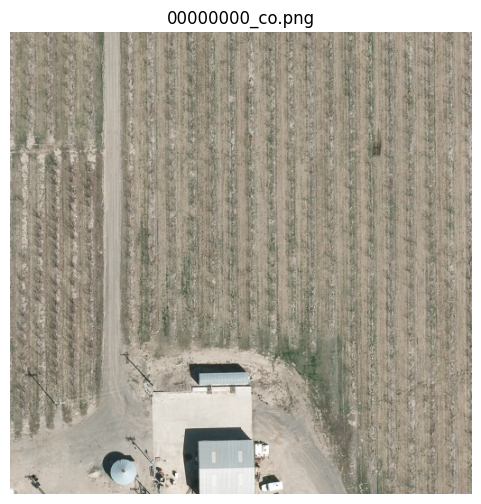

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(colour_images[0].name)
plt.axis("off")
plt.show()

### colour vs infrared pair

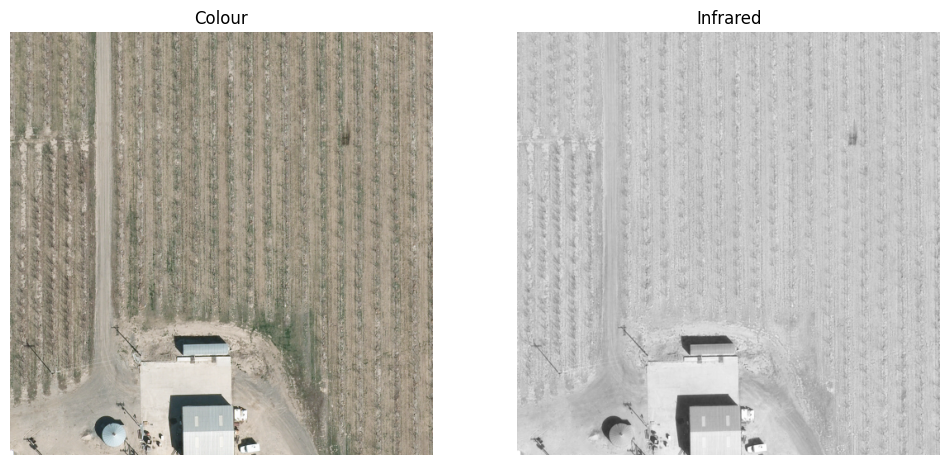

In [6]:
base_id = "00000000"

colour = Image.open(IMG_DIR / f"{base_id}_co.png")
infrared = Image.open(IMG_DIR / f"{base_id}_ir.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(colour)
axes[0].set_title("Colour")

axes[1].imshow(infrared, cmap="gray")
axes[1].set_title("Infrared")

for ax in axes:
    ax.axis("off")

plt.show()

### Inspect annotations

In [7]:
sample_annotation = annotation_files[0]

print("File:", sample_annotation.name)

with open(sample_annotation, "r") as f:
    lines = f.readlines()

print(f"Vehicles in image: {len(lines)}")

for line in lines[:10]:
    print(line.strip())

File: 00000000.txt
Vehicles in image: 1
290.348971 504.611640 3.012318 2 1 0 277 303 304 279 502 498 508 511


In [8]:
first_row = lines[0].strip().split()

print("Columns:", len(first_row))

for i, value in enumerate(first_row):
    print(f"Column {i}: {value}")

Columns: 14
Column 0: 290.348971
Column 1: 504.611640
Column 2: 3.012318
Column 3: 2
Column 4: 1
Column 5: 0
Column 6: 277
Column 7: 303
Column 8: 304
Column 9: 279
Column 10: 502
Column 11: 498
Column 12: 508
Column 13: 511


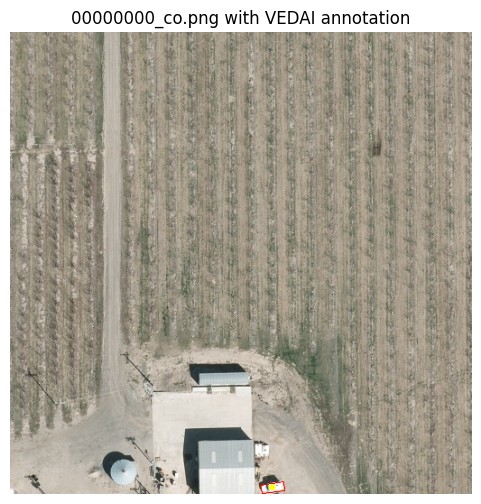

In [9]:
from PIL import ImageDraw

base_id = "00000000"

img = Image.open(IMG_DIR / f"{base_id}_co.png").convert("RGB")
ann_path = ANN_DIR / f"{base_id}.txt"

draw = ImageDraw.Draw(img)

with open(ann_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if not parts:
            continue

        x_c = float(parts[0])
        y_c = float(parts[1])
        class_id = int(parts[3])

        xs = list(map(float, parts[6:10]))
        ys = list(map(float, parts[10:14]))

        polygon = list(zip(xs, ys))

        draw.polygon(polygon, outline="red")
        draw.ellipse((x_c - 3, y_c - 3, x_c + 3, y_c + 3), fill="yellow")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"{base_id}_co.png with VEDAI annotation")
plt.axis("off")
plt.show()

### Investigate Classes

In [10]:
from collections import Counter

class_counter = Counter()

for ann_file in annotation_files:

    with open(ann_file, "r") as f:
        for line in f:

            parts = line.strip().split()

            if len(parts) == 14:
                class_id = int(parts[3])
                class_counter[class_id] += 1

print("Class frequencies:")
for cls, count in sorted(class_counter.items()):
    print(f"Class {cls}: {count:,}")

Class frequencies:
Class 1: 1,377
Class 2: 307
Class 4: 190
Class 5: 397
Class 7: 4
Class 8: 3
Class 9: 101
Class 10: 204
Class 11: 955
Class 23: 171
Class 31: 48


In [12]:
colour_ids = {p.stem.replace("_co", "") for p in colour_images}
annotation_ids = {
    p.stem for p in annotation_files
    if p.stem.isdigit()
}

missing_images = sorted(annotation_ids - colour_ids)
missing_annotations = sorted(colour_ids - annotation_ids)

print("Colour image IDs:", len(colour_ids))
print("Numeric annotation IDs:", len(annotation_ids))
print("Annotations without colour image:", len(missing_images))
print("Colour images without annotation:", len(missing_annotations))

print("First missing images:", missing_images[:10])
print("First missing annotations:", missing_annotations[:10])

Colour image IDs: 1246
Numeric annotation IDs: 1246
Annotations without colour image: 0
Colour images without annotation: 0
First missing images: []
First missing annotations: []


In [13]:
usable_ids = sorted(colour_ids & annotation_ids)

vehicle_count = 0
empty_annotations = 0

for img_id in usable_ids:
    ann_path = ANN_DIR / f"{img_id}.txt"
    with open(ann_path, "r") as f:
        lines = [line for line in f.readlines() if line.strip()]
    
    vehicle_count += len(lines)
    if len(lines) == 0:
        empty_annotations += 1

print("Usable colour image/annotation pairs:", len(usable_ids))
print("Total vehicles in usable colour set:", vehicle_count)
print("Empty annotation files:", empty_annotations)

Usable colour image/annotation pairs: 1246
Total vehicles in usable colour set: 3757
Empty annotation files: 0
